In [31]:
# Aula I.A. conteudo prova pratica AR - 11/05/26
# Arvore de decisao - mercado financeiro

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [51]:
# Gerando base para trabalhar

np.random.seed(32)
n = 300

# Renda mensal
renda = np.random.randint(1500, 20001, n)

# Score de credito
score = np.random.randint(200, 1001, n)

# Divida atual
divida = np.random.randint(0, 50001, n)

# Quantidade de atrasos
atrasos = np.random.randint(0, 11, n)

In [74]:
# variavel alvo
aprovado_credito = (
    (score >= 650) &
    (renda >= 4000) &
    (divida <= 25000) &  # 15000
    (atrasos <= 2)
).astype(int)

In [63]:
# Dataframe
base = pd.DataFrame({
    'renda': renda,
    'score': score,
    'divida': divida,
    'atrasos': atrasos,
    'aprovado_credito': aprovado_credito
})

print(base.head())

   renda  score  divida  atrasos  aprovado_credito
0  12467    773    2503        7                 0
1  11271    746   25576        1                 0
2  11026    447   41514        7                 0
3   8245    821   24272        1                 1
4  14785    746   24804        8                 0


In [64]:
x = base[['renda', 'score', 'divida', 'atrasos']]
y = base['aprovado_credito']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=32)

# Construindo um modelo
model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 4,
    random_state = 32
)

In [69]:
# Treinando o modelo
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,32
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
# Previsoes
previsoes = model.predict(x_test)

In [71]:
# Acuracia
acc = accuracy_score(y_test, previsoes)
print(acc)

0.9888888888888889


In [72]:
# Matriz de confusao
matrix = confusion_matrix(y_test, previsoes)
print(matrix)

[[84  0]
 [ 1  5]]


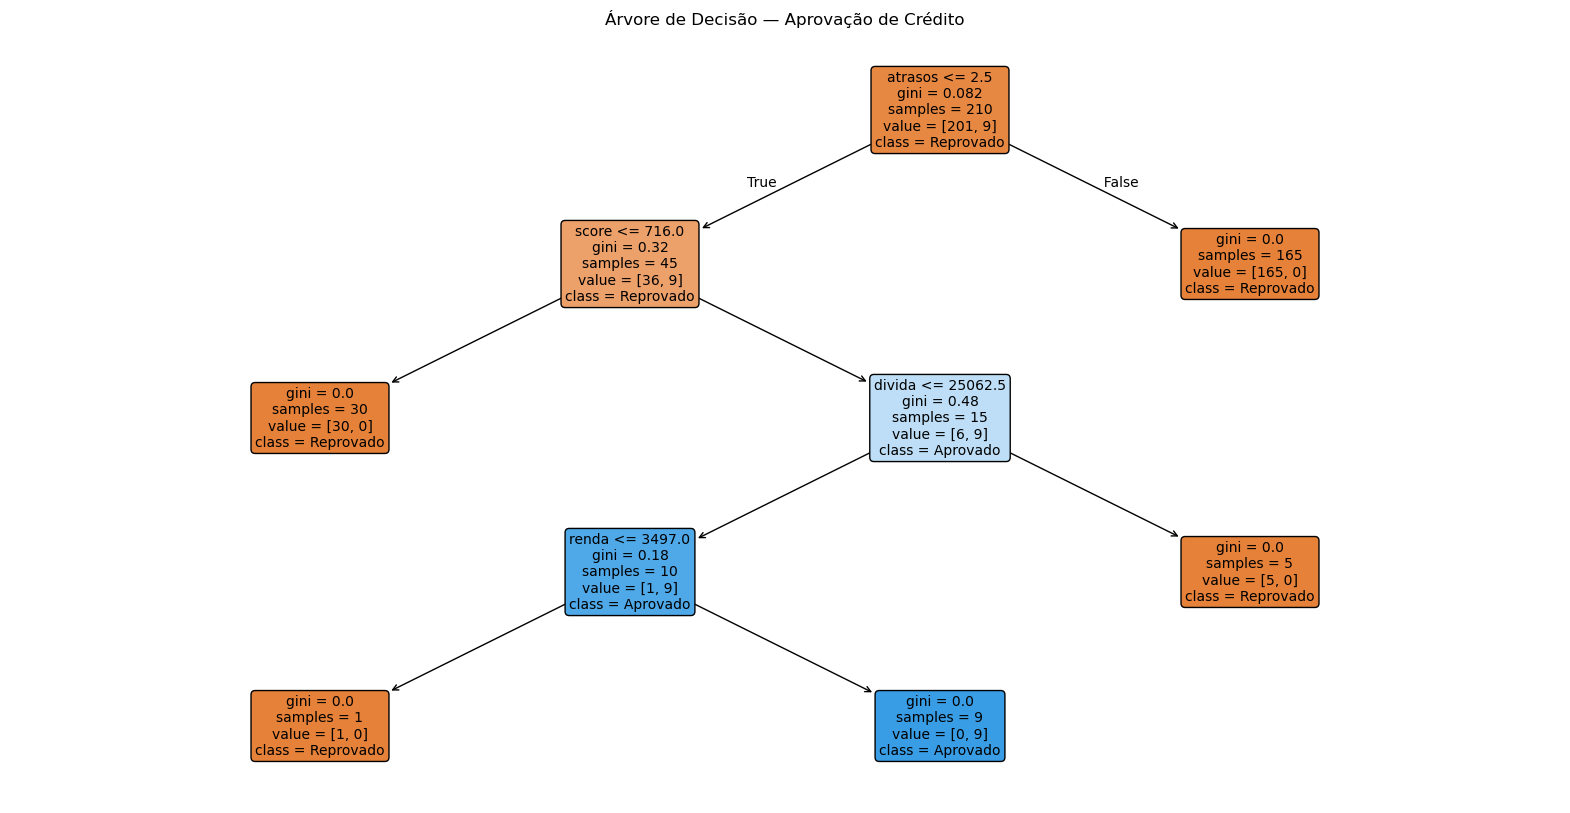

In [73]:
# Exibir
plt.figure(figsize=(20,10))
 
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['Reprovado', 'Aprovado'],
    filled=True,
    rounded=True,
    fontsize=10
)
 
plt.title('Árvore de Decisão — Aprovação de Crédito')
plt.show()